# **`Inatel - C24 (Inteligência Artificial) - 2026/1`**

# <font color='green'>**Atividade 06: Classificação**</font>

## <font color='#2D9CDB'>**LEIA ATENTAMENTE AS INSTRUÇÕES A SEGUIR**</font>
- Importe este notebook no [Google Colab](https://colab.research.google.com/) para resolver os exercícios;
- Consulte o material disponibilizado pelo Prof. Felipe Figueiredo para revisar os conceitos;
- Utilize os recursos disponíveis na Internet (documentações e artigos científicos) para complementar seus estudos;
- <font color='red'>**A ATIVIDADE DEVERÁ SER REALIZADA COM O [MONITOR](mailto:matheus.botelho@ges.inatel.br) EM UM DOS SEGUINTES HORÁRIOS:**</font>

| Monitor                       | Dia           | Hora                               | Local           |
|-------------------------------|---------------|------------------------------------|---------------- |
| Matheus Botelho Sampaio Netto | Terça-feira   | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Quinta-feira  | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>10:00</font> | Teams (ao vivo) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>13:30</font> | Teams (ao vivo) |

- <font color='red'>**NÃO**</font> remova as células de Código já presentes neste notebook;
- <font color='red'>**NÃO**</font> modifique as células de Markdown (em <font color='green'>verde</font> ou <font color='#2D9CDB'>azul</font>) presentes neste notebook;
- Após cada questão, há uma célula para você implementar e responder a questão;
- É permitido adicionar mais células (de código ou markdown) antes da próxima pergunta;
- Caso precise utilizar bibliotecas que não estão instaladas nativamente no Colab, inclua uma célula de código com o comando de instalação.</font>
  - Exemplo: `!pip install nome_da_biblioteca`
- <font color='red'>**Renomeie os termos `LL` para `sua_turma_de_laboratorio` e `MMMM` para `seu_numero_de_matricula` no nome do arquivo.**</font>
  - Exemplo: `C24_2026_1_L1_Atividade_06_1234.ipynb`)
- <font color='magenta'>**Faça download do notebook com a resolução no Google Colab, mantendo a saída de todas as células, e anexe-o à tarefa do Teams.**</font>

# <font color='green'><u><b>Preparação</b></u></font>

In [16]:
!pip install numpy pandas matplotlib seaborn scikit-learn ucimlrepo

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# <font color='green'><u><b>Parte 1 - Classificação Binária</b></u></font>

### <font color='#2D9CDB'>Acesse o link indicado e, em um único parágrafo, descreva brevemente o dataset, incluindo: domínio de aplicação, objetivo da base de dados e o tipo de informações que ela contém.</font>
- #### <font color='#2D9CDB'>Iranian Churn Dataset (2020). UCI Machine Learning Repository.</font>
  - #### <font color='#2D9CDB'>https://doi.org/10.24432/C5JW3Z</font>
  - #### <font color='#2D9CDB'>https://archive-beta.ics.uci.edu/dataset/563/iranian+churn+dataset</font>

O dataset é uma base de dados do setor de telecomunicações criada para estudos de previsão de churn, reunindo 3.150 registros de clientes com informações como falhas em chamadas, frequência de SMS, reclamações, tempo de assinatura, idade, tipo de serviço, uso e valor cobrado, além da variável alvo “churn”, que indica se o cliente permaneceu ou cancelou o serviço após 12 meses.



In [18]:
# fetch dataset
ds = fetch_ucirepo(id=563)

# metadata
display(ds.metadata)

# variable information
display(ds.variables)

# data (as pandas dataframe)
df = pd.concat([ds.data.features, ds.data.targets], axis='columns')

{'uci_id': 563,
 'name': 'Iranian Churn',
 'repository_url': 'https://archive.ics.uci.edu/dataset/563/iranian+churn+dataset',
 'data_url': 'https://archive.ics.uci.edu/static/public/563/data.csv',
 'abstract': "This dataset is randomly collected from an Iranian telecom company's database over a period of 12 months.",
 'area': 'Business',
 'tasks': ['Classification', 'Regression'],
 'characteristics': ['Multivariate'],
 'num_instances': 3150,
 'num_features': 13,
 'feature_types': ['Integer'],
 'demographics': ['Age'],
 'target_col': ['Churn'],
 'index_col': None,
 'has_missing_values': 'no',
 'missing_values_symbol': None,
 'year_of_dataset_creation': 2020,
 'last_updated': 'Sat Mar 09 2024',
 'dataset_doi': '10.24432/C5JW3Z',
 'creators': [],
 'intro_paper': None,
 'additional_info': {'summary': 'This dataset is randomly collected from an Iranian telecom companyâ€™s database over a period of 12 months. A total of 3150 rows of data, each representing a customer, bear information for 13

,name,role,type,demographic,description,units,missing_values
0,Call Failure,Feature,Integer,None,None,None,no
1,Complains,Feature,Binary,None,None,None,no
2,Subscription Length,Feature,Integer,None,None,None,no
3,Charge Amount,Feature,Integer,None,None,None,no
4,Seconds of Use,Feature,Integer,None,None,None,no
5,Frequency of use,Feature,Integer,None,None,None,no
6,Frequency of SMS,Feature,Integer,None,None,None,no
7,Distinct Called Numbers,Feature,Integer,None,None,None,no
8,Age Group,Feature,Integer,Age,None,None,no
9,Tariff Plan,Feature,Integer,None,None,None,no


### <font color='#2D9CDB'>Q1) Exiba as primeiras linhas do dataframe, verifique suas dimensões e identifique a variável alvo (`TARGET_COLUMN`), respondendo com base nos resultados obtidos: quantas amostras e atributos o dataset possui, qual é o nome da variável alvo e se o problema é de classificação binária (justifique observando os valores únicos da variável alvo).</font>

In [19]:
print(df.head())

   Call  Failure  Complains  Subscription  Length  Charge  Amount  \
0              8          0                    38               0   
1              0          0                    39               0   
2             10          0                    37               0   
3             10          0                    38               0   
4              3          0                    38               0   

   Seconds of Use  Frequency of use  Frequency of SMS  \
0            4370                71                 5   
1             318                 5                 7   
2            2453                60               359   
3            4198                66                 1   
4            2393                58                 2   

   Distinct Called Numbers  Age Group  Tariff Plan  Status  Age  \
0                       17          3            1       1   30   
1                        4          2            1       2   25   
2                       24          3    

In [20]:
print(df.shape)

(3150, 14)


In [21]:
TARGET_COLUMN = "Churn" # preencher

O dataset possui 3150 amostras e 14 atributos (incluindo a variável alvo), sendo Churn a variável alvo; trata-se de um problema de classificação binária, pois essa variável assume apenas dois valores (0 e 1), indicando respectivamente clientes que não cancelaram e que cancelaram o serviço.

### <font color='#2D9CDB'>Q2) Plote a distribuição da variável alvo utilizando o gráfico fornecido e, com base no resultado obtido, analise a proporção entre as classes para determinar se o dataset é balanceado ou desbalanceado, justificando sua resposta a partir da contagem de amostras em cada classe.</font>

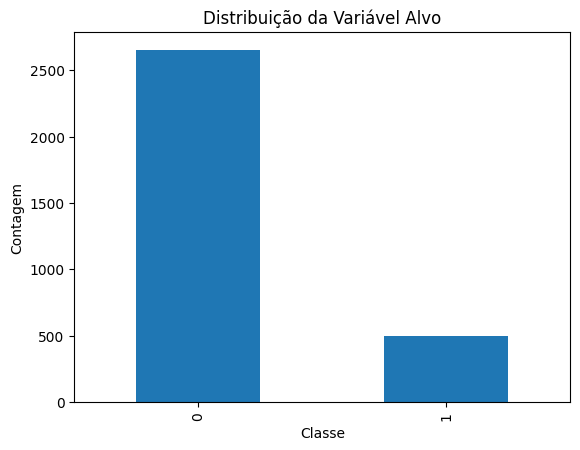

In [22]:
df[TARGET_COLUMN].value_counts().plot(kind='bar')
plt.xlabel('Classe')
plt.ylabel('Contagem')
plt.title('Distribuição da Variável Alvo')
plt.show()

In [23]:
print(df[TARGET_COLUMN].value_counts())

Churn
0    2655
1     495
Name: count, dtype: int64


### <font color='#2D9CDB'>Q3) Gere a matriz de correlação entre os atributos do dataset e a variável alvo utilizando o gráfico fornecido e, com base nos valores apresentados, identifique quais atributos possuem maior correlação (positiva ou negativa) com a variável alvo, indicando quais podem ser mais relevantes para o problema de classificação.</font>

Text(0.5, 1.0, 'Matriz de Correlação dos Atributos com a Variável Alvo')

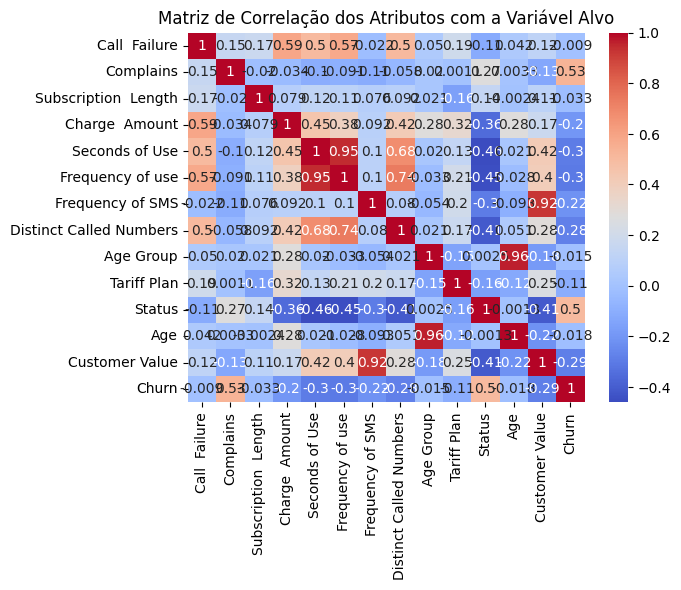

In [24]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Matriz de Correlação dos Atributos com a Variável Alvo')

In [25]:
print(df.corr()['Churn'].sort_values(ascending=False))

Churn                      1.000000
Complains                  0.532053
Status                     0.498976
Call  Failure             -0.008987
Age Group                 -0.014550
Age                       -0.017705
Subscription  Length      -0.032588
Tariff Plan               -0.105853
Charge  Amount            -0.202305
Frequency of SMS          -0.220754
Distinct Called Numbers   -0.278867
Customer Value            -0.289144
Seconds of Use            -0.298935
Frequency of use          -0.303337
Name: Churn, dtype: float64


Os mais relevantes serão aqueles que tem um valor muito alto na correlação (negativo ou positivo), sendo eles 'Complains' (0.53) e 'Frequency of use' (-0.3)

### <font color='#2D9CDB'>Q4) Aplique a técnica de Análise de Componentes Principais (PCA) para projetar os dados em duas dimensões e gere um gráfico de dispersão (scatter plot) utilizando as duas primeiras componentes principais, colorindo os pontos de acordo com a variável alvo; antes de aplicar o PCA, padronize os dados utilizando `StandardScaler`; em seguida, com base na visualização obtida, analise se há separação entre as classes e justifique sua resposta considerando a presença ou não de sobreposição entre os grupos.</font>

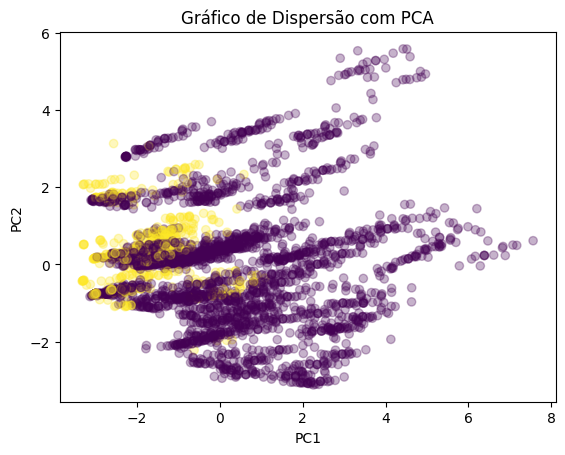

In [26]:
X = df.drop(TARGET_COLUMN, axis=1)
y = df[TARGET_COLUMN]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, alpha=0.3)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Gráfico de Dispersão com PCA')
plt.show()

Com base na projeção dos dados em duas dimensões pelo PCA, observa-se que não há uma separação clara entre as classes, pois os pontos correspondentes a clientes que cancelaram e os que permaneceram se sobrepõem em diversas regiões do gráfico; isso indica que as duas primeiras componentes principais não capturam uma estrutura que diferencie bem os grupos, sugerindo que o problema não apresenta separabilidade linear evidente e que será necessário explorar mais atributos ou técnicas avançadas para melhorar a classificação.

### <font color='#2D9CDB'>Q5) Separe o dataset em variáveis de entrada (`X`) e variável alvo (`y`), divida os dados em conjuntos de treino e teste utilizando `train_test_split` (com 20% para teste) e `random_state=42`, e aplique a padronização dos atributos com `StandardScaler`; em seguida, explique por que a padronização é importante nesse contexto e por que o `fit` deve ser aplicado apenas no conjunto de treino.

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

Assim, garantimos que todos os atributos fiquem na mesma escala, evitando que variáveis com valores maiores dominem o processo de aprendizado e influenciem indevidamente o modelo; além disso, o fit deve ser aplicado apenas no conjunto de treino para que o modelo aprenda a partir de dados conhecidos e depois seja capaz de generalizar para dados novos, evitando vazamento de informação do conjunto de teste e garantindo uma avaliação justa do desempenho.

### <font color='#2D9CDB'>Q6) Treine um modelo de regressão logística utilizando os dados de treino (`X_train`, `y_train`) e, após o treinamento, verifique se o modelo convergiu corretamente; em seguida, descreva qual é o papel desse modelo no contexto do problema e o que ele está aprendendo a partir dos dados.</font>

In [37]:
log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train)
print(log_reg.n_iter_)

[42]


O modelo está aprendendo relações entre as variáveis explicativas e o alvo. Ele transforma combinações lineares das features em probabilidades e, a partir disso, decide a classe. Isso é fundamental em problemas de classificação, pois permite não só prever rótulos, mas também medir o grau de confiança em cada previsão.

### <font color='#2D9CDB'>Q7) Utilize o modelo treinado para calcular as probabilidades previstas para o conjunto de teste (`predict_proba`) e exiba algumas delas; em seguida, interprete os valores obtidos explicando o que cada coluna representa e analise se o modelo está fazendo previsões com alta ou baixa confiança, com base na proximidade dos valores de 0 e 1.</font>

In [39]:
X_test_scaled = scaler.transform(X_test)
y_proba = log_reg.predict_proba(X_test_scaled)

print(y_proba)

[[9.98819220e-01 1.18078042e-03]
 [9.99954113e-01 4.58869561e-05]
 [9.74259483e-01 2.57405165e-02]
 ...
 [4.06197690e-01 5.93802310e-01]
 [9.98730727e-01 1.26927321e-03]
 [9.93839937e-01 6.16006346e-03]]


O predict_proba mostra o grau de certeza do modelo em cada previsão. Quanto mais próximo de 0 ou de 1, o modelo é mais confiável, a coluna 0 representa a probabilidade da amostra pertencer à classe 0 e a coluna 1 a probabilidade de pertencer à classe 1.

### <font color='#2D9CDB'>Q8) Utilize as probabilidades previstas para gerar classificações com dois limiares diferentes (0.5 e 0.7) e compare os resultados obtidos; em seguida, analise como a alteração do limiar afeta as previsões do modelo, especialmente em relação à quantidade de falsos positivos e falsos negativos.</font>

In [44]:
y_proba = log_reg.predict_proba(X_test_scaled)[:, 1]
y_pred_05 = (y_proba >= 0.5).astype(int)
y_pred_07 = (y_proba >= 0.7).astype(int)

print(y_pred_05)
print(y_pred_07)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 1 0 0 1 0 0 0 0 1 0 0 0 0 0
 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0
 1 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1
 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 1 1 0 0 0 0 1 0 0 

Alterar o limiar muda o equilíbrio entre falsos positivos e falsos negativos. Um limiar mais baixo (0.5) tem maior sensibilidade, detecta mais casos positivos, mas arrisca marcar alguns exemplos incorretamente como positivos.Um limiar mais alto (0.7) tem maior precisão, só marca como positivo quando há alta confiança, mas pode deixar passar casos que realmente pertencem à classe positiva.

### <font color='#2D9CDB'>Q9) Calcule as métricas de desempenho (acurácia, precisão, recall e F1-score) e a matriz de confusão para os dois limiares de decisão (0.5 e 0.7) utilizando a função fornecida e, com base nos resultados obtidos, compare o desempenho do modelo, identificando qual métrica foi mais impactada pela mudança do limiar e discutindo o trade-off observado entre precisão e recall.</font>

In [46]:
print("Limiar 0.5:")
print("Acurácia:", accuracy_score(y_test, y_pred_05))
print("Precisão:", precision_score(y_test, y_pred_05))
print("Recall:", recall_score(y_test, y_pred_05))
print("F1-score:", f1_score(y_test, y_pred_05))
print("Matriz de confusão:\n", confusion_matrix(y_test, y_pred_05))

print("\nLimiar 0.7:")
print("Acurácia:", accuracy_score(y_test, y_pred_07))
print("Precisão:", precision_score(y_test, y_pred_07))
print("Recall:", recall_score(y_test, y_pred_07))
print("F1-score:", f1_score(y_test, y_pred_07))
print("Matriz de confusão:\n", confusion_matrix(y_test, y_pred_07))

Limiar 0.5:
Acurácia: 0.8698412698412699
Precisão: 0.7333333333333333
Recall: 0.4
F1-score: 0.5176470588235295
Matriz de confusão:
 [[504  16]
 [ 66  44]]

Limiar 0.7:
Acurácia: 0.873015873015873
Precisão: 0.8571428571428571
Recall: 0.32727272727272727
F1-score: 0.47368421052631576
Matriz de confusão:
 [[514   6]
 [ 74  36]]


 A métrica mais impactada pela mudança do limiar é o recall, que diminui significativamente quando aumentamos o limiar. Isso mostra o clássico trade-off entre precisão e recall: ao exigir maior confiança para prever positivos, ganhamos em precisão, mas sacrificamos a capacidade de detectar todos os casos positivos.

# <font color='green'><u><b>Parte 2 - Classificação Multiclasse</b></u></font>

### <font color='#2D9CDB'>Acesse o link indicado e, em um único parágrafo, descreva brevemente o dataset, incluindo: domínio de aplicação, objetivo da base de dados e o tipo de informações que ela contém.</font>
- #### <font color='#2D9CDB'>Blackard, J. (1998). Covertype Dataset. UCI Machine Learning Repository.</font>
  - #### <font color='#2D9CDB'>https://doi.org/10.24432/C50K5N</font>
  - #### <font color='#2D9CDB'>https://archive-beta.ics.uci.edu/dataset/31/covertype</font>

O Covertype Dataset é uma base de dados do domínio de ecologia e geociências, criada para prever o tipo de cobertura florestal em áreas do norte do Colorado a partir de variáveis cartográficas, sem uso de sensoriamento remoto. O objetivo é classificar cada célula de 30 x 30 metros em uma das sete categorias de cobertura florestal, utilizando atributos derivados de dados do USGS e do US Forest Service, como elevação, declividade, orientação, distâncias a rios e estradas, além de variáveis binárias que indicam tipos de solo e áreas de preservação. Trata-se de um conjunto extenso, com mais de 580 mil instâncias e 54 atributos, que permite explorar técnicas de classificação e análise ambiental em cenários reais de ecossistemas florestais .

In [50]:
# fetch dataset
ds = fetch_ucirepo(id=31)

# metadata
display(ds.metadata)

# variable information
display(ds.variables)

# data (as pandas dataframe)
df = pd.concat([ds.data.features, ds.data.targets], axis='columns').sample(frac=0.10, random_state=42)

{'uci_id': 31,
 'name': 'Covertype',
 'repository_url': 'https://archive.ics.uci.edu/dataset/31/covertype',
 'data_url': 'https://archive.ics.uci.edu/static/public/31/data.csv',
 'abstract': 'Classification of pixels into 7 forest cover types based on attributes such as elevation, aspect, slope, hillshade, soil-type, and more.',
 'area': 'Biology',
 'tasks': ['Classification'],
 'characteristics': ['Multivariate'],
 'num_instances': 581012,
 'num_features': 54,
 'feature_types': ['Categorical', 'Integer'],
 'demographics': [],
 'target_col': ['Cover_Type'],
 'index_col': None,
 'has_missing_values': 'no',
 'missing_values_symbol': None,
 'year_of_dataset_creation': 1998,
 'last_updated': 'Sat Mar 16 2024',
 'dataset_doi': '10.24432/C50K5N',
 'creators': ['Jock Blackard'],
 'intro_paper': None,
 'additional_info': {'summary': 'Predicting forest cover type from cartographic variables only (no remotely sensed data).  The actual forest cover type for a given observation (30 x 30 meter cell

,name,role,type,demographic,description,units,missing_values
0,Elevation,Feature,Integer,None,None,None,no
1,Aspect,Feature,Integer,None,None,None,no
2,Slope,Feature,Integer,None,None,None,no
3,Horizontal_Distance_To_Hydrology,Feature,Integer,None,None,None,no
4,Vertical_Distance_To_Hydrology,Feature,Integer,None,None,None,no
5,Horizontal_Distance_To_Roadways,Feature,Integer,None,None,None,no
6,Hillshade_9am,Feature,Integer,None,None,None,no
7,Hillshade_Noon,Feature,Integer,None,None,None,no
8,Hillshade_3pm,Feature,Integer,None,None,None,no
9,Horizontal_Distance_To_Fire_Points,Feature,Integer,None,None,None,no


### <font color='#2D9CDB'>Q10) Exiba as primeiras linhas do dataframe, verifique suas dimensões e identifique a variável alvo (`TARGET_COLUMN`), respondendo com base nos resultados obtidos: quantas amostras e atributos o dataset possui, qual é o nome da variável alvo e se o problema é de classificação binária (justifique observando os valores únicos da variável alvo).</font>

In [51]:
df.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Wilderness_Area2,Wilderness_Area3,Wilderness_Area4,Cover_Type
250728,3351,206,27,726,124,3813,192,252,180,2271,...,0,0,0,1,0,0,0,0,0,1
246788,2732,129,7,212,1,1082,231,236,137,912,...,0,0,0,0,0,0,0,1,0,2
407714,2572,24,9,201,25,957,216,222,142,2191,...,0,0,0,0,0,0,0,1,0,2
25713,2824,69,13,417,39,3223,233,214,110,6478,...,0,0,0,0,0,0,0,0,0,2
21820,2529,84,5,120,9,1092,227,231,139,4983,...,0,0,0,0,0,0,0,0,0,2


In [52]:
df.shape

(58101, 55)

In [53]:
TARGET_COLUMN = 'Cover_Type' # preencher

O problema não é de classsificação binária, temos mais de duas classes oara classificar a amostra.

### <font color='#2D9CDB'>Q11) Plote a distribuição da variável alvo utilizando o gráfico fornecido e, com base no resultado obtido, analise a proporção entre as classes para determinar se o dataset é balanceado ou desbalanceado, justificando sua resposta a partir da contagem de amostras em cada classe.</font>

In [56]:
df[TARGET_COLUMN].value_counts()

,count
Cover_Type,
2,28248
1,21297
3,3607
7,2052
6,1706
5,932
4,259


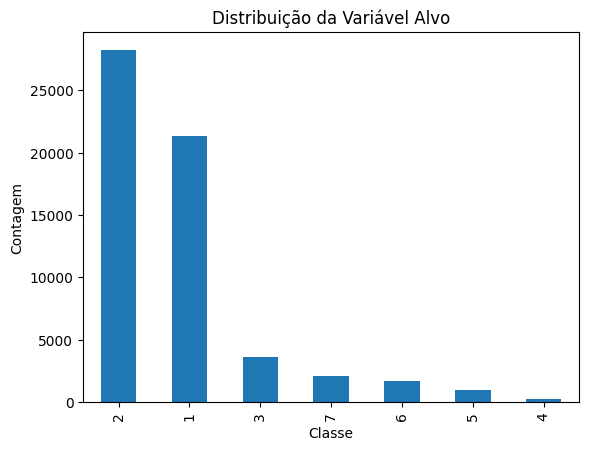

In [55]:
df[TARGET_COLUMN].value_counts().plot(kind='bar')
plt.xlabel('Classe')
plt.ylabel('Contagem')
plt.title('Distribuição da Variável Alvo')
plt.show()

O dataset está bem desbalanceado, podemos observar que temos mais amostras da classe 2 e menos na classe 4, podendo impactar o noso modelo.

### <font color='#2D9CDB'>Q12) Gere a correlação entre os atributos e a variável alvo, ordene os valores e plote um gráfico de barras horizontais; destaque, no gráfico, os atributos com maior correlação em valor absoluto utilizando linhas de referência em |r| = 0.2 (valor adotado como um limiar heurístico para indicar correlações moderadas); em seguida, com base nos resultados, identifique quais variáveis podem ser mais relevantes para o modelo. Opcionalmente, pode-se imprimir os valores de correlação para facilitar a verificação numérica dos resultados e complementar a análise visual do gráfico.</font>

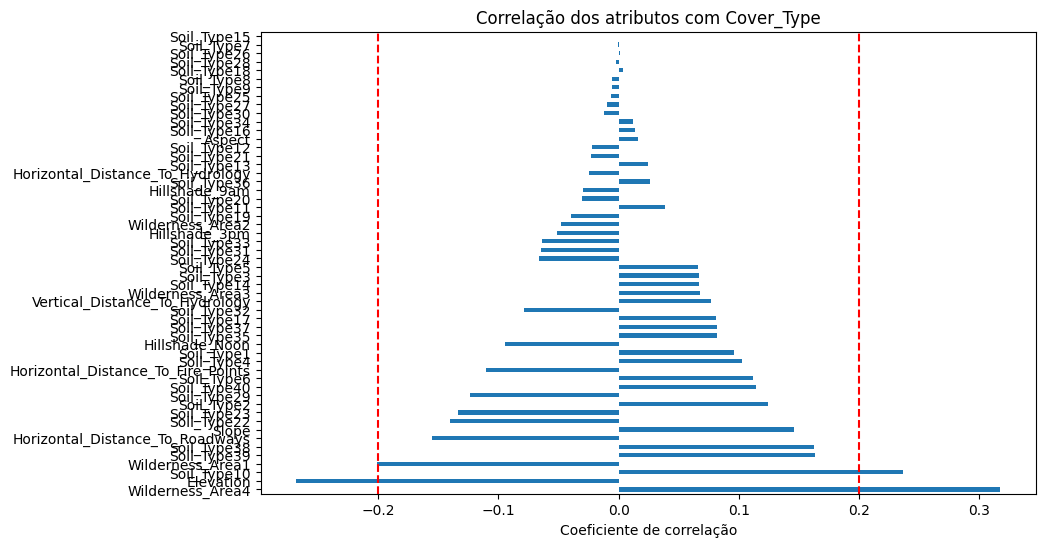

In [62]:
correlations = df.corr()[TARGET_COLUMN].drop(TARGET_COLUMN).sort_values(key=abs, ascending=False)

plt.figure(figsize=(10,6))
correlations.plot(kind="barh")
plt.axvline(x=0.2, color="red", linestyle="--")
plt.axvline(x=-0.2, color="red", linestyle="--")
plt.title("Correlação dos atributos com Cover_Type")
plt.xlabel("Coeficiente de correlação")
plt.show()

In [64]:
print(correlations.sort_values(ascending=False))

Wilderness_Area4                      0.317518
Soil_Type10                           0.236392
Soil_Type39                           0.163504
Soil_Type38                           0.162663
Slope                                 0.145731
Soil_Type2                            0.124545
Soil_Type40                           0.114002
Soil_Type6                            0.111851
Soil_Type4                            0.102949
Soil_Type1                            0.096215
Soil_Type35                           0.082155
Soil_Type37                           0.082139
Soil_Type17                           0.080860
Vertical_Distance_To_Hydrology        0.076705
Wilderness_Area3                      0.067601
Soil_Type14                           0.067192
Soil_Type3                            0.066948
Soil_Type5                            0.066202
Soil_Type11                           0.038734
Soil_Type36                           0.025927
Soil_Type13                           0.024600
Aspect       

 Ao observar o gráfico, os atributos que ultrapassam o limiar |r| = 0.2 devem ser considerados mais relevantes para o modelo, pois contribuem de forma mais significativa para a classificação das classes de Cover_Type.

### <font color='#2D9CDB'>Q13) Aplique a técnica de Análise de Componentes Principais (PCA) para projetar os dados em duas dimensões e gere um gráfico de dispersão (scatter plot) utilizando as duas primeiras componentes principais, colorindo os pontos de acordo com a variável alvo; em seguida, com base na visualização obtida, analise se há separação entre as classes e justifique sua resposta considerando a presença ou não de sobreposição entre os grupos.</font>

Text(0.5, 1.0, 'Gráfico de Dispersão com PCA')

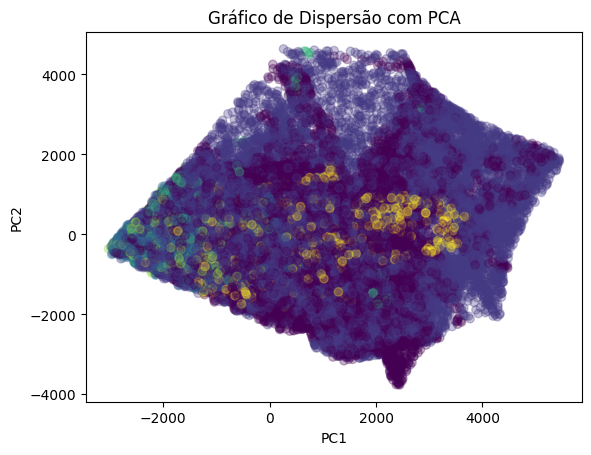

In [67]:
X = df.drop(TARGET_COLUMN, axis=1)
y = df[TARGET_COLUMN]

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, alpha=0.3)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Gráfico de Dispersão com PCA')

O PCA em duas dimensões ajuda a visualizar a estrutura dos dados, mostrando que há alguma separação entre classes, mas também bastante interseção, o que confirma a necessidade de técnicas de classificação robustas para lidar com o dataset.

### <font color='#2D9CDB'>Q14) Separe o dataset em variáveis de entrada (`X`) e variável alvo (`y`), divida os dados em conjuntos de treino e teste utilizando `train_test_split` (com 20% para teste) e `random_state=42`, aplique a padronização dos atributos com `StandardScaler` e instancie um objeto de validação cruzada `KFold` com 5 divisões; em seguida, explique por que a validação cruzada (k-fold cross-validation) é importante para avaliar o desempenho de modelos de classificação.</font>

In [68]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

A validação cruzada permite avaliar de forma mais justa e confiável como o modelo se comportará em dados novos, equilibrando o uso do dataset e evitando conclusões enviesadas.

### <font color='#2D9CDB'>Q15) Utilize o objeto `KFold` instanciado anteriormente para treinar e avaliar um modelo de regressão logística multiclasse ao longo dos 5 folds no conjunto de treino, aplicando a padronização dentro de cada fold; durante o treinamento, exiba o número de iterações (`n_iter_`) em cada fold e verifique se o modelo convergiu corretamente; em seguida, reporte a média das métricas obtidas e descreva o papel do modelo no contexto do problema e o que ele está aprendendo a partir dos dados.</font>

In [71]:
accuracies, precisions, recalls, f1s = [], [], [], []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr)
    X_val_scaled = scaler.transform(X_val)

    log_reg = LogisticRegression(multi_class="multinomial", solver="lbfgs")
    log_reg.fit(X_tr_scaled, y_tr)
    print(f"Fold {fold+1} - n_iter_: {log_reg.n_iter_}")

    y_pred = log_reg.predict(X_val_scaled)
    accuracies.append(accuracy_score(y_val, y_pred))
    precisions.append(precision_score(y_val, y_pred, average="macro"))
    recalls.append(recall_score(y_val, y_pred, average="macro"))
    f1s.append(f1_score(y_val, y_pred, average="macro"))

print("Média Acurácia:", np.mean(accuracies))
print("Média Precisão:", np.mean(precisions))
print("Média Recall:", np.mean(recalls))
print("Média F1-score:", np.mean(f1s))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'mul

Fold 1 - n_iter_: [100]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From 

Fold 2 - n_iter_: [100]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Fold 3 - n_iter_: [100]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From 

Fold 4 - n_iter_: [100]
Fold 5 - n_iter_: [100]
Média Acurácia: 0.7260972461273666
Média Precisão: 0.5885134265081498
Média Recall: 0.5000970752687854
Média F1-score: 0.5196584659966342


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


O modelo funciona como um classificador probabilístico, mas o trade-off observado mostra que ele tem maior acurácia geral do que capacidade de recuperar todas as classes, e ajustes como aumento de max_iter, regularização ou técnicas de balanceamento podem melhorar seu desempenho.

### <font color='#2D9CDB'>Q16) Treine um modelo final de regressão logística utilizando todo o conjunto de treino (`X_train`, `y_train`), aplicando regularização L2 (padrão do `scikit-learn`) com `C=0.01`; em seguida, aplique a padronização adequada e utilize o modelo para calcular as probabilidades previstas no conjunto de teste (`predict_proba`); exiba algumas dessas probabilidades e interprete os valores obtidos, explicando o que cada coluna representa e analisando se o modelo está fazendo previsões com alta ou baixa confiança.</font>

In [72]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg_final = LogisticRegression(C=0.01, penalty="l2", multi_class="multinomial", solver="lbfgs", max_iter=1000)
log_reg_final.fit(X_train_scaled, y_train)

y_proba_test = log_reg_final.predict_proba(X_test_scaled)

print(y_proba_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


[[4.56718481e-01 5.23084183e-01 6.39284902e-05 9.02739482e-05
  3.08497108e-03 8.75511493e-05 1.68706112e-02]
 [3.83918030e-02 4.50020779e-01 1.52924004e-01 4.51295588e-04
  1.32717895e-02 3.44410291e-01 5.30037883e-04]
 [2.24398140e-01 7.34051460e-01 3.88706013e-03 3.30029562e-04
  2.16104420e-02 1.14592292e-02 4.26363915e-03]
 [2.37864629e-01 7.45047850e-01 9.41347793e-04 8.67305481e-05
  1.12881709e-02 2.02220183e-03 2.74906990e-03]
 [1.15367020e-01 7.28306959e-01 7.65292658e-03 1.30015908e-04
  3.49590343e-02 1.13242686e-01 3.41358172e-04]]


cada coluna representa a probabilidade de uma classe específica de cobertura florestal. O modelo com regularização L2 e C=0.01 tende a ser mais conservador, evitando coeficientes muito grandes, o que pode resultar em previsões menos extremas (probabilidades mais moderadas), refletindo maior cautela na classificação.

### <font color='#2D9CDB'>Q17) Treine um modelo de regressão logística sem regularização (`penalty=None`) utilizando o mesmo procedimento de padronização e conjunto de treino; em seguida, calcule as probabilidades previstas no conjunto de teste (`predict_proba`), exiba algumas delas (usando os mesmos índices de amostras da questão anterior) e analise os resultados novamente.</font>

In [73]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg_no_reg = LogisticRegression(penalty=None, multi_class="multinomial", solver="lbfgs", max_iter=1000)
log_reg_no_reg.fit(X_train_scaled, y_train)

y_proba_test_no_reg = log_reg_no_reg.predict_proba(X_test_scaled)

print(y_proba_test_no_reg)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


[[4.77904679e-01 5.12566466e-01 1.21550291e-08 ... 1.65999685e-03
  4.64212188e-09 7.86882759e-03]
 [3.10922536e-02 4.29935336e-01 1.07349805e-01 ... 1.29503034e-02
  4.18670810e-01 2.53819741e-09]
 [1.99335256e-01 7.75793729e-01 9.01252328e-04 ... 2.25777668e-02
  1.31798815e-03 7.35199359e-05]
 ...
 [9.50376580e-02 8.92603415e-01 2.22152393e-03 ... 8.66246874e-03
  1.45761472e-03 1.71386317e-05]
 [4.82802111e-02 6.24721788e-01 6.97611547e-03 ... 1.79250466e-01
  1.40768341e-01 2.34104225e-07]
 [4.81052513e-01 5.12919015e-01 4.02529208e-08 ... 5.93148856e-03
  6.61417181e-09 9.69367001e-05]]


Cada coluna continua representando a probabilidade de uma classe específica, mas sem regularização o modelo tende a ser mais “confiante” (probabilidades extremas), o que pode parecer bom em termos de certeza, mas pode comprometer a capacidade de generalização em dados novos.

### <font color='#2D9CDB'>Q18) Compare as probabilidades previstas pelos modelos com e sem regularização e analise as diferenças observadas, considerando: (i) a concentração das probabilidades em uma única classe, (ii) o nível de confiança das previsões e (iii) possíveis indícios de overfitting; para apoiar sua análise, calcule a confiança média dos modelos (considerando, para cada amostra, a maior probabilidade prevista) e utilize esse valor na comparação.</font>

In [74]:
conf_reg = np.mean(np.max(y_proba_test, axis=1))

conf_no_reg = np.mean(np.max(y_proba_test_no_reg, axis=1))

print("Confiança média (com regularização):", conf_reg)
print("Confiança média (sem regularização):", conf_no_reg)


Confiança média (com regularização): 0.7024909029483848
Confiança média (sem regularização): 0.7275706595353355


Com regularização (C=0.01) as previsões são mais moderadas, menor confiança média, maior robustez contra overfitting. Sem regularização as previsões são mais extremas, maior confiança média, mas maior risco de overfitting.

### <font color='#2D9CDB'>Q19) Utilize o `classification_report` para avaliar o desempenho dos modelos com e sem regularização no conjunto de teste; em seguida, compare os resultados obtidos, analisando as métricas de precisão, recall e F1-score para cada classe e discutindo possíveis diferenças no desempenho entre os modelos.</font>

In [75]:
y_pred_reg = log_reg_final.predict(X_test_scaled)
print(classification_report(y_test, y_pred_reg))

y_pred_no_reg = log_reg_no_reg.predict(X_test_scaled)
print(classification_report(y_test, y_pred_no_reg))


              precision    recall  f1-score   support

           1       0.71      0.70      0.70      4163
           2       0.75      0.81      0.78      5759
           3       0.62      0.84      0.71       720
           4       0.40      0.11      0.17        55
           5       1.00      0.01      0.01       178
           6       0.51      0.12      0.20       339
           7       0.67      0.52      0.58       407

    accuracy                           0.72     11621
   macro avg       0.67      0.44      0.45     11621
weighted avg       0.72      0.72      0.71     11621

              precision    recall  f1-score   support

           1       0.71      0.70      0.70      4163
           2       0.76      0.80      0.78      5759
           3       0.64      0.79      0.71       720
           4       0.58      0.35      0.43        55
           5       0.50      0.01      0.01       178
           6       0.47      0.22      0.30       339
           7       0.70 

O modelo com regularização (C=0.01, L2) apresenta desempenho mais equilibrado e robusto, mesmo que suas previsões sejam menos “extremas”. O modelo sem regularização mostra maior confiança aparente, mas com métricas desbalanceadas entre classes, sugerindo menor capacidade de generalização.

### <font color='#2D9CDB'>Q20) Calcule a matriz de confusão normalizada (por linha, com duas casas de precisão) para os modelos com e sem regularização no conjunto de teste; em seguida, plote ambas as matrizes e compare os resultados, analisando quais classes são melhor classificadas, quais apresentam maior confusão e como a regularização impacta o desempenho entre as classes.</font>

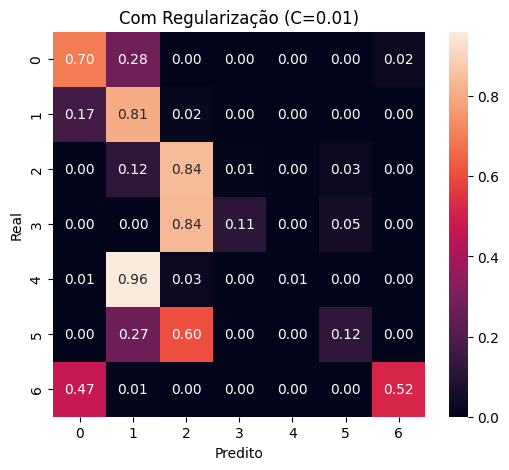

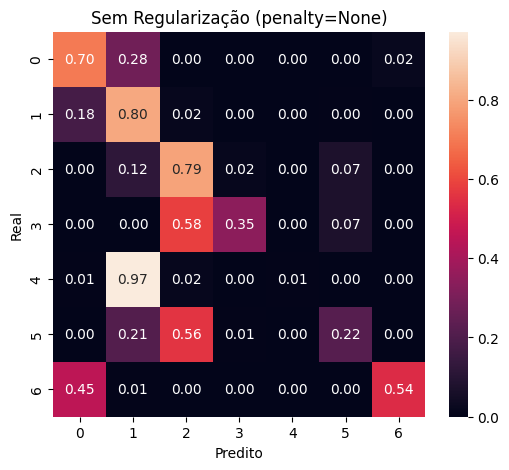

In [79]:
cm_reg = confusion_matrix(y_test, y_pred_reg, normalize='true')
cm_no_reg = confusion_matrix(y_test, y_pred_no_reg, normalize='true')

plt.figure(figsize=(6,5))
sns.heatmap(cm_reg, annot=True, fmt=".2f")
plt.title("Com Regularização (C=0.01)")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()

plt.figure(figsize=(6,5))
sns.heatmap(cm_no_reg, annot=True, fmt=".2f")
plt.title("Sem Regularização (penalty=None)")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()

 A regularização ajuda a suavizar os coeficientes, reduzindo a confiança excessiva em poucas classes e melhorando a capacidade de generalização, especialmente em problemas multiclasse e desbalanceados.